<a href="https://colab.research.google.com/github/eniompw/microgpt/blob/main/microgpt_fast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [ ]:
import os, random, json
import torch
import torch.nn.functional as F

random.seed(42); torch.manual_seed(42)  # reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device.type == 'cuda' else ''))


Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Download and Preparation

In [ ]:
if not os.path.exists('input.txt'):
    import warnings, pandas as pd
    warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')
    df = pd.read_parquet("hf://datasets/karpathy/tinystories-gpt4-clean/tinystories_gpt4_clean.parquet")
    with open('input.txt', 'w') as f:
        for s in df['text'].iloc[20000:25000]:  # 5000 stories
            f.write(json.dumps(s) + '\n')

docs = [json.loads(l) for l in open('input.txt') if l.strip()]
random.shuffle(docs)
print(f"docs: {len(docs)}, sample: {docs[0][:80]}...")


input.txt already exists, skipping download.
num docs: 5000
sample doc: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira was very strong and gentle, and she lik...


## 3. Tokenizer Setup

In [ ]:
# Character-level vocab — 74 printable ASCII chars + BOS (beginning-of-story) token
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars); vocab_size = BOS + 1

# Encode / decode helpers
stoi = {c: i for i, c in enumerate(uchars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)
print(f"vocab: {vocab_size}, BOS: {BOS}")


vocab size: 75
BOS token id: 74
encode('Once upon a time') → [36, 61, 50, 52, 1, 68, 63, 62, 61, 1, 48, 1, 67, 56, 60, 52]
decode(...)           → 'Once upon a time'


## 4. Model Hyperparameters and Parameter Initialization

In [ ]:
import math

# ── Hyperparameters ──────────────────────────────────────────────────────────
n_layer    = 6       # transformer depth
n_embd     = 256     # embedding dim
block_size = 256     # context window
n_head     = 8       # attention heads
head_dim   = n_embd // n_head
batch_size = 64      # sequences per gradient step

# Weight init — scale down randn; .requires_grad_(True) on result makes it an optimisable leaf tensor
W = lambda r, c: (torch.randn(r, c, device=device) * 0.02).requires_grad_(True)
sd = {'wte': W(vocab_size, n_embd)}  # token embeddings — reused as lm_head (weight tying)
for i in range(n_layer):
    sd |= {f'l{i}.wq': W(n_embd, n_embd), f'l{i}.wk': W(n_embd, n_embd),  # attention Q, K, V, O
           f'l{i}.wv': W(n_embd, n_embd), f'l{i}.wo': W(n_embd, n_embd),
           f'l{i}.fc1': W(4*n_embd, n_embd), f'l{i}.fc2': W(n_embd, 4*n_embd)}  # MLP
params = list(sd.values())
print(f"params: {sum(p.numel() for p in params):,}")


num params: 4,737,792
tokens per iter: 16,384


## 5. Model Architecture Definition

Llama-style transformer: RMSNorm, RoPE, flash attention, weight tying.
The core forward pass stays explicit for teaching; only boilerplate is factored out elsewhere.

In [ ]:
def rmsnorm(x):
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()  # normalise without mean subtraction

# RoPE — precompute cos/sin rotation tables once; reused every forward pass
t = torch.arange(block_size, device=device).float()
f = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
rope_cos, rope_sin = torch.outer(t, f).cos(), torch.outer(t, f).sin()  # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    # Rotate pairs of dimensions to encode relative position into q/k vectors
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))  # split last dim into (head_dim//2, 2) pairs
    x0, x1 = x[..., 0], x[..., 1]
    if x.dim() == 5:  # batched (B,T,H,D) → reshape cos/sin to broadcast over B, H
        cos = cos.view(1, -1, 1, cos.shape[-1])
        sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x0*cos - x1*sin, x0*sin + x1*cos], -1).flatten(-2).to(d)

# ── Batched forward (for training) ───────────────────────────────────────────
def gpt_train(tokens):
    """tokens: (B, T) long → logits (B, T, vocab_size)"""
    B, T = tokens.shape
    x = rmsnorm(F.embedding(tokens, sd['wte']))
    cos, sin = rope_cos[:T], rope_sin[:T]
    for i in range(n_layer):
        r = x; x = rmsnorm(x)
        q = F.linear(x, sd[f'l{i}.wq']).view(B, T, n_head, head_dim)
        k = F.linear(x, sd[f'l{i}.wk']).view(B, T, n_head, head_dim)
        v = F.linear(x, sd[f'l{i}.wv']).view(B, T, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(             # flash attention — fused CUDA kernel
            q.transpose(1,2), k.transpose(1,2), v.transpose(1,2), is_causal=True
        ).transpose(1,2).reshape(B, T, -1)
        x = F.linear(x, sd[f'l{i}.wo']) + r            # output projection + residual
        r = x; x = rmsnorm(x)
        x = F.silu(F.linear(x, sd[f'l{i}.fc1']))       # SiLU activation (smoother than ReLU)
        x = F.linear(x, sd[f'l{i}.fc2']) + r
    return F.linear(rmsnorm(x), sd['wte'])              # weight-tied lm_head

gpt_train = torch.compile(gpt_train)  # fuse GPU kernels for ~2× speedup
print(f"torch.compile cache: {os.getenv('TORCHINDUCTOR_CACHE_DIR', '~/.cache/torch/inductor')}")

# ── Single-token forward (for inference with KV cache) ───────────────────────
def gpt(token_id, pos_id, keys, values):
    x = rmsnorm(sd['wte'][token_id])
    cos, sin = rope_cos[pos_id], rope_sin[pos_id]
    for i in range(n_layer):
        r = x; x = rmsnorm(x)
        q = F.linear(x, sd[f'l{i}.wq']).view(n_head, head_dim)
        k = F.linear(x, sd[f'l{i}.wk']).view(n_head, head_dim)
        v = F.linear(x, sd[f'l{i}.wv']).view(n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        keys[i].append(k)
        values[i].append(v)
        K = torch.stack(keys[i])    # (S, H, D)
        V = torch.stack(values[i])  # (S, H, D)
        attn = F.softmax(torch.einsum('hd,shd->sh', q, K) / head_dim**0.5, dim=0)
        x = F.linear(torch.einsum('sh,shd->hd', attn, V).reshape(-1),
                      sd[f'l{i}.wo']) + r
        r = x; x = rmsnorm(x)
        x = F.silu(F.linear(x, sd[f'l{i}.fc1']))
        x = F.linear(x, sd[f'l{i}.fc2']) + r
    return F.linear(rmsnorm(x), sd['wte'])


torch.compile cache: /tmp/torchinductor_root
Model functions defined.


## 6. Training Loop

Total tokens: 4,051,708
step    0/3500 | loss 5.2415 | lr 0.00e+00 | 3.4s
step  100/3500 | loss 2.1986 | lr 5.00e-04 | 10.3s
step  200/3500 | loss 1.5609 | lr 1.00e-03 | 15.7s
step  300/3500 | loss 1.2518 | lr 9.98e-04 | 21.3s
step  400/3500 | loss 1.1309 | lr 9.92e-04 | 27.0s
step  500/3500 | loss 1.0971 | lr 9.82e-04 | 32.8s
step  600/3500 | loss 1.0185 | lr 9.68e-04 | 38.9s
step  700/3500 | loss 0.9518 | lr 9.50e-04 | 44.9s
step  800/3500 | loss 0.9211 | lr 9.29e-04 | 50.7s
step  900/3500 | loss 0.9246 | lr 9.04e-04 | 56.3s
step 1000/3500 | loss 0.9002 | lr 8.76e-04 | 61.8s
step 1100/3500 | loss 0.8451 | lr 8.45e-04 | 67.2s
step 1200/3500 | loss 0.8432 | lr 8.11e-04 | 72.6s
step 1300/3500 | loss 0.8044 | lr 7.75e-04 | 78.0s
step 1400/3500 | loss 0.7990 | lr 7.37e-04 | 83.4s
step 1500/3500 | loss 0.7823 | lr 6.97e-04 | 88.8s
step 1600/3500 | loss 0.7598 | lr 6.56e-04 | 94.2s
step 1700/3500 | loss 0.7418 | lr 6.14e-04 | 99.7s
step 1800/3500 | loss 0.7655 | lr 5.71e-04 | 105.2s
step 19

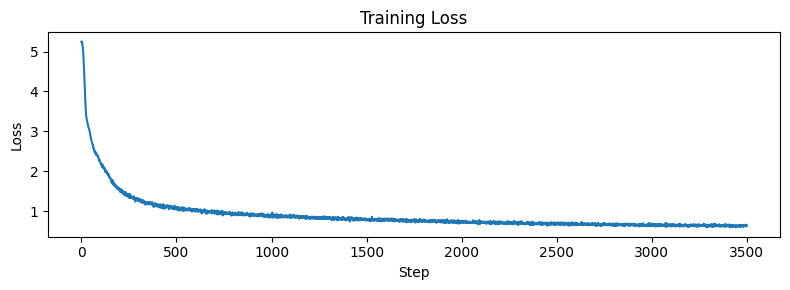

In [ ]:
import time
import matplotlib.pyplot as plt

# Flatten all stories into a single token stream with BOS markers as story boundaries
all_tokens = torch.tensor(
    [tok for doc in docs for tok in [BOS] + encode(doc)] + [BOS],
    dtype=torch.long, device=device
)

def get_batch():
    # Sample batch_size random windows of block_size tokens from the stream
    s = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,), device=device)
    idx = s.unsqueeze(1) + torch.arange(block_size + 1, device=device)
    tokens = all_tokens[idx]
    return tokens[:, :-1], tokens[:, 1:]  # inputs, targets (shifted by 1 for next-token prediction)

# ── Optimizer: AdamW ─────────────────────────────────────────────────────────
num_steps  = 3500   # total training steps
warmup     = 200    # steps to linearly ramp LR up from 0 (stabilises early training)
lr         = 1e-3   # peak learning rate
min_lr     = 1e-4   # 10% of peak — prevents wasted steps at tail

def get_lr(step):
    # Linear warmup then cosine decay to min_lr floor
    if step < warmup:
        return lr * step / warmup
    p = (step - warmup) / (num_steps - warmup)
    return min_lr + (lr - min_lr) * 0.5 * (1 + math.cos(math.pi * p))

opt = torch.optim.AdamW(params, lr=lr, betas=(0.9, 0.95), eps=1e-10, fused=(device.type == 'cuda'))
scaler = torch.amp.GradScaler('cuda')  # scales loss to prevent float16 gradient underflow
losses, t0 = [], time.time()

for step in range(num_steps + 1):
    opt.param_groups[0]['lr'] = get_lr(step)  # update LR each step
    if step % 100 == 0:
        xb, yb = get_batch()
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            loss_val = F.cross_entropy(gpt_train(xb).reshape(-1, vocab_size), yb.reshape(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {loss_val:.4f} | lr {get_lr(step):.2e} | {time.time()-t0:.1f}s")
    if step >= num_steps: break
    opt.zero_grad(set_to_none=True)
    xb, yb = get_batch()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(gpt_train(xb).reshape(-1, vocab_size), yb.reshape(-1))
    scaler.scale(loss).backward()
    scaler.unscale_(opt)
    torch.nn.utils.clip_grad_norm_(params, 1.0)  # prevent loss spikes from large gradients
    scaler.step(opt); scaler.update()
    losses.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(losses); plt.xlabel('Step'); plt.ylabel('Loss'); plt.tight_layout(); plt.show()


## 7. Inference and Text Generation

In [ ]:
num_samples    = 5    # number of stories to generate
max_new_tokens = 200  # max tokens per story (stops early if BOS token is predicted)
temperature    = 0.7  # lower = more focused, higher = more random

def generate_sample(max_new_tokens=200, temperature=0.7):
    keys = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            logits = gpt(token_id, min(pos_id, block_size - 1), keys, values)
            probs = F.softmax(logits[:vocab_size] / temperature, dim=-1)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    return ''.join(sample)

t0 = time.time()
for i in range(num_samples):
    print(f"--- sample {i+1} ---\n{generate_sample(max_new_tokens, temperature)}\n")
print(f"Done in {time.time()-t0:.1f}s")


--- inference (hallucinated stories) ---

sample 1:
Once upon a time, there was a big girl named Amy. She liked to talk and speak. She had many friends who never care of her animals like her big eyes. She was very happy and wanted to help her friend.
A

sample 2:
Once upon a time, there was a little girl named Amy. She liked to play with her ball and dream a hole. One day, she found a big box in her room. She wanted to paint, but it was the best at from the sh

sample 3:
One day, a little girl named Mia went to the park. She saw a big cardboard box. Mia wanted to play the bird too. She went in and enjoyed the bird that he had found a big picture. Mia wanted to be smal

sample 4:
One day, a little boy named Tim went to the park. He saw a big tree and said to the tree, "Can I play with the tree, please?" Tim said, "Yes, please!" They both sit on the tree and share the tree.
Whe

sample 5:
Once upon a time, there was a little boy named Tim. He loved to measure his favorite toy. One day, h